# 5DATA002W.2 - Machine Learning & Data Mining
## Final Python Notebook 1: Data Understanding and Preprocessing
**Author:** Muditha Dodamwala - 20233064/W2120414

### Peer Code Review Record
* **Reviewer Name:** Yehara Kobbegala - 20231956/ w2120659
* **Date of Review:** 13 April 2026
* **Tests Checked During Review:**
  1. Checked that `dropna` correctly removed nulls in the target variable without affecting valid data rows.
  2. Verified the categorical encoding correctly generated one-hot encoded variables.
  3. Confirmed code cells are properly commented and match the Analysis Report requirements.

In [16]:
# Import the pandas library to handle data manipulation and dataframes
import pandas as pd
# Import the matplotlib.pyplot module to create static plots and charts
import matplotlib.pyplot as plt
# Import the seaborn library to create statistical data visualizations
import seaborn as sns

# Load the loan dataset from a CSV file into a pandas DataFrame (Upload your file to Colab first!)
df = pd.read_csv('loan_approval_data (1).csv')

# Display the first 5 rows of the dataset to verify it loaded correctly
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


Source Reference: Code Reuse Session 1 - Task 2: Exploring and Understanding the Dataset. Producing basic descriptive stats, variable scales, and target distribution.

,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


,Data Type
id,int64
age,float64
income,int64
home_ownership,object
emplyment_length,int64
loan_intent,object
loan_amount,int64
loan_interest_rate,float64
loan_income_ratio,float64
payment_default_on_file,object


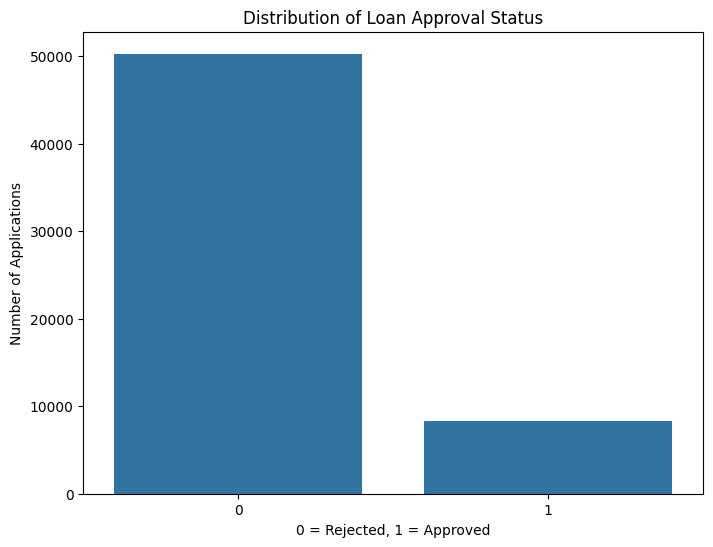

In [17]:
# Generate basic descriptive statistics for all numerical features in the dataframe
descriptive_stats = df.describe()
# Display the descriptive statistics table using rich formatting
display(descriptive_stats)

# Retrieve the data types (scale types) for every column in the dataframe
data_types = df.dtypes
# Convert data types to a dataframe and display it using rich formatting
display(pd.DataFrame(data_types, columns=['Data Type']))

# Set the figure size for the upcoming distribution plot
plt.figure(figsize=(8, 6))
# Create a count plot to visualize the distribution of the target variable using the correct column name 'loan_approval_status'
sns.countplot(x='loan_approval_status', data=df)
# Add the X-Label (This goes at the bottom)
plt.xlabel('0 = Rejected, 1 = Approved')
# Add the Y-Label (This goes on the left side)
plt.ylabel('Number of Applications')
# Add a title to the distribution plot for clarity
plt.title('Distribution of Loan Approval Status')
# Display the generated plot to the screen
plt.show()

Source Reference: Code Reuse Session 1 - Task 3: Data Preparation: Cleaning and Transforming. Checking for missing values and dropping unnecessary columns.

In [18]:
# Calculate the total number of missing values for each column in the dataframe
missing_values_before = df.isnull().sum()
# Print the missing values to the console to use as 'Before' evidence
print("Missing values before fix:\n", missing_values_before)

# Display a separator line for readability in the console output
print("\n--- Minimum Values Before Fix ---")
# Print the minimum value of interest rate to prove it is negative
print("Min loan_interest_rate:", df['loan_interest_rate'].min())
# Print the minimum value of max allowed loan to prove it is negative
print("Min max_allowed_loan:", df['max_allowed_loan'].min())
# Print the maximum value of age to prove the 123-year-old outlier exists
print("Max age:", df['age'].max())

Missing values before fix:
 id                          0
age                         6
income                      0
home_ownership              0
emplyment_length            0
loan_intent                 0
loan_amount                 0
loan_interest_rate         11
loan_income_ratio           0
payment_default_on_file     5
credit_history_length       0
loan_approval_status        0
max_allowed_loan            0
dtype: int64

--- Minimum Values Before Fix ---
Min loan_interest_rate: -11.14
Min max_allowed_loan: -2426900
Max age: 123.0


Source Reference: Code Reuse Session 1 - Task 3: Data Preparation (Executing Fixes and Generating "After" Evidence).

In [19]:
# Fix 1: Impute missing values for 'age' using the median value of the age column
df['age'] = df['age'].fillna(df['age'].median())
# Impute missing values for 'loan_interest_rate' using the median interest rate
df['loan_interest_rate'] = df['loan_interest_rate'].fillna(df['loan_interest_rate'].median())

# Fix 2: Convert negative loan interest rate values to positive using the absolute function
df['loan_interest_rate'] = df['loan_interest_rate'].abs()
# Convert negative max allowed loan values to positive using the absolute function
df['max_allowed_loan'] = df['max_allowed_loan'].abs()

# Fix 3: Remove outlier rows by keeping only rows where age is 100 years or less
df = df[df['age'] <= 100]
# Remove outlier rows by keeping only rows where employment length is 100 years or less
df = df[df['emplyment_length'] <= 100]

# Fix 4: Drop the 'id' column (ignoring errors if it was already dropped in the previous cell)
df = df.drop(columns=['id'], errors='ignore')

# --- Verification (The 'After' evidence) ---
# Calculate the missing values again to prove they are resolved
missing_values_after = df.isnull().sum()
# Print the new missing values count to the console
print("Missing values after fix:\n", missing_values_after)

# Display a separator line for readability in the console output
print("\n--- Values After Fix ---")
# Print the fixed minimum interest rate
print("Min loan_interest_rate:", df['loan_interest_rate'].min())
# Print the fixed minimum max allowed loan
print("Min max_allowed_loan:", df['max_allowed_loan'].min())
# Print the fixed maximum age to prove the outlier is gone
print("Max age:", df['age'].max())

Missing values after fix:
 age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    5
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64

--- Values After Fix ---
Min loan_interest_rate: 5.42
Min max_allowed_loan: 0
Max age: 84.0


Source Reference: Code Reuse Session 1 - Task 3: Data Preparation (Splitting into Classification and Regression Datasets).

In [20]:
# --- 1. Classification Dataset ---
# Drop 'max_allowed_loan' to prevent data leakage, as it's determined after approval
df_classification = df.drop(columns=['max_allowed_loan'])

# Save the classification dataset to a new CSV file for Notebook 2
df_classification.to_csv('loan_classification_data.csv', index=False)
# Print confirmation to the console
print("Classification dataset shape:", df_classification.shape)


# --- 2. Regression Dataset ---
# Filter the dataframe to only include rows where the loan was approved (status == 1)
df_regression = df[df['loan_approval_status'] == 0].copy()

# Drop 'loan_approval_status' as it is now redundant (all are approved)
df_regression = df_regression.drop(columns=['loan_approval_status'])

# Save the regression dataset to a new CSV file for Notebook 3
df_regression.to_csv('loan_regression_data.csv', index=False)
# Print confirmation to the console
print("Regression dataset shape:", df_regression.shape)

Classification dataset shape: (58641, 11)
Regression dataset shape: (50292, 11)
